# PENDAHULUAN

## Latar Belakang
Dalam industri pengembangan gim modern, khususnya pada genre *Action Role-Playing Game* (ARPG), desain karakter melibatkan keseimbangan matematis yang sangat kompleks. Setiap karakter diciptakan dengan identitas visual dan mekanik yang unik, namun di baliknya terdapat struktur data statistik yang menentukan performa mereka. Statistik dasar seperti *Health Points* (HP), *Attack* (ATK), dan *Defense* (DEF) tidak ditentukan secara acak, melainkan mengikuti pola tertentu yang disesuaikan dengan jenis senjata dan peran mereka dalam tim.

Penggunaan teknologi *Machine Learning* dalam analisis data gim memungkinkan pengembang maupun komunitas untuk membedah pola-pola ini secara otomatis. Dengan mengklasifikasikan jenis senjata berdasarkan statistik dasar, kita dapat membangun model prediktif yang memahami hubungan antara angka statistik dengan kebutuhan peralatan karakter. Proyek ini memfokuskan pada penggunaan algoritma klasifikasi untuk memetakan bagaimana atribut fisik karakter menentukan jenis senjata yang paling optimal bagi mereka.

## Urgensi Proyek
Analisis klasifikasi ini memiliki tingkat urgensi yang tinggi dikarenakan beberapa alasan berikut:

* **Optimalisasi Game Design:** Mengetahui pola statistik membantu perancang gim dalam menciptakan karakter baru agar tetap seimbang dan memastikan statistik dasar tetap relevan dengan senjata yang digunakan.
* **Automasi Sistem Rekomendasi:** Model ini menjadi fondasi bagi sistem rekomendasi otomatis dalam menentukan strategi atau *build* karakter yang paling efektif secara matematis.
* **Efisiensi Pengolahan Data:** Seiring bertambahnya jumlah karakter, analisis manual menjadi tidak praktis. *Machine Learning* menawarkan solusi cepat untuk mengelompokkan data karakter dalam skala besar.
* **Validasi Konsistensi Data:** Proyek ini berfungsi sebagai alat audit untuk memastikan bahwa data karakter yang dirilis tetap konsisten terhadap aturan desain yang telah ditetapkan.

## Rumusan Masalah
Masalah yang diangkat dalam proyek ini meliputi:
* Bagaimana tahap *preprocessing* yang tepat untuk menangani data kategorikal agar dapat diolah oleh algoritma klasifikasi?
* Atribut statistik manakah yang memiliki pengaruh paling signifikan terhadap penentuan jenis senjata?
* Di antara berbagai algoritma yang diuji, manakah yang memberikan performa akurasi terbaik pada dataset ini?
* Seberapa akurat model tersebut jika diuji untuk memprediksi jenis senjata pada data karakter baru?

## Tujuan Proyek
* Melakukan normalisasi dan transformasi data mentah menggunakan teknik *Scaling* dan *Encoding*.
* Menganalisis korelasi antar variabel atribut karakter melalui visualisasi *Heatmap*.
* Membangun dan membandingkan performa lima model klasifikasi *Machine Learning*.
* Menguji kemampuan prediktif model melalui simulasi data karakter fiktif untuk penerapan praktis.

#Library

Sel ini berfungsi untuk memuat semua pustaka (*library*) yang dibutuhkan dalam proyek.
* **Pandas & Numpy:** Digunakan untuk mengolah data tabel dan perhitungan matematika.
* **Matplotlib & Seaborn:** Digunakan untuk membuat grafik dan visualisasi data.
* **Sklearn (Scikit-learn):** Library utama untuk pemrosesan data (seperti *encoding* dan *scaling*) serta pembuatan model Machine Learning.
* **Joblib:** Digunakan untuk menyimpan model yang sudah dilatih agar bisa langsung digunakan kembali tanpa proses latihan ulang.

In [ ]:
# =========================
# Data Manipulation
# =========================
import pandas as pd
import numpy as np

# =========================
# Data Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Preprocessing
# =========================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =========================
# Machine Learning Models
# =========================
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# =========================
# Evaluation Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# =========================
# Implemntasi
# =========================
import joblib

#Data Understanding

Pada tahap ini, dataset dibaca ke dalam sistem.
* `pd.read_csv()`: Mengambil data dari file eksternal (CSV) ke dalam bentuk tabel (DataFrame).
* `df.info()`: Digunakan untuk mengecek struktur data, termasuk jumlah baris, kolom, dan apakah ada data yang rusak atau tipe datanya tidak sesuai.

In [ ]:
df = pd.read_csv('Genshin_Impact_All_Character_Stat.csv')

In [ ]:
print("--- Info Dataset ---")
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Character  574 non-null    object
 1   Lv         574 non-null    int64 
 2   Rarity     574 non-null    int64 
 3   Element    574 non-null    object
 4   Weapon     574 non-null    object
 5   Main role  574 non-null    object
 6   Ascension  574 non-null    object
 7   Base HP    574 non-null    int64 
 8   Base ATK   574 non-null    int64 
 9   Base DEF   574 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 45.0+ KB


In [ ]:
print("\n--- Statistik Deskriptif ---")
df.describe(include='all')


--- Statistik Deskriptif ---


,Character,Lv,Rarity,Element,Weapon,Main role,Ascension,Base HP,Base ATK,Base DEF
count,574,574.000000,574.000000,574,574,574,574,574.000000,574.000000,574.000000
unique,41,NaN,NaN,7,5,4,15,NaN,NaN,NaN
top,Amber,NaN,NaN,Pyro,Sword,DPS,ATK,NaN,NaN,NaN
freq,14,NaN,NaN,126,140,210,112,NaN,NaN,NaN
mean,NaN,52.214286,4.512195,NaN,NaN,NaN,NaN,6860.010453,148.527875,423.303136
std,NaN,24.996567,0.500287,NaN,NaN,NaN,NaN,3325.201592,77.011853,202.560931
min,NaN,1.000000,4.000000,NaN,NaN,NaN,NaN,763.000000,8.000000,48.000000
25%,NaN,40.000000,4.000000,NaN,NaN,NaN,NaN,4405.000000,91.250000,276.000000
50%,NaN,55.000000,5.000000,NaN,NaN,NaN,NaN,6942.500000,148.000000,431.000000
75%,NaN,70.000000,5.000000,NaN,NaN,NaN,NaN,9280.000000,200.750000,575.000000


In [ ]:
print("\n--- Sampel Data ---")
df.head()


--- Sampel Data ---


,Character,Lv,Rarity,Element,Weapon,Main role,Ascension,Base HP,Base ATK,Base DEF
0,Amber,1,4,Pyro,Bow,Sub DPS,ATK,793,19,50
1,Amber,20,4,Pyro,Bow,Sub DPS,ATK,2038,48,129
2,Amber,20,4,Pyro,Bow,Sub DPS,ATK,2630,62,167
3,Amber,40,4,Pyro,Bow,Sub DPS,ATK,3940,93,250
4,Amber,40,4,Pyro,Bow,Sub DPS,ATK,4361,103,277


#Preprocessing

Sel ini memastikan data yang digunakan berkualitas tinggi.
* **Cek Missing Value:** Memastikan tidak ada kolom yang kosong.
* **Metode IQR (Interquartile Range):** Digunakan untuk mendeteksi data yang "aneh" atau terlalu ekstrem (*outlier*) agar tidak mengganggu keakuratan prediksi model nantinya.

In [ ]:
df.isnull().sum()

,0
Character,0
Lv,0
Rarity,0
Element,0
Weapon,0
Main role,0
Ascension,0
Base HP,0
Base ATK,0
Base DEF,0


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nKolom: {col}")
    print(f"Jumlah outlier: {len(outliers)}")


Kolom: Lv
Jumlah outlier: 0

Kolom: Rarity
Jumlah outlier: 0

Kolom: Base HP
Jumlah outlier: 0

Kolom: Base ATK
Jumlah outlier: 0

Kolom: Base DEF
Jumlah outlier: 0


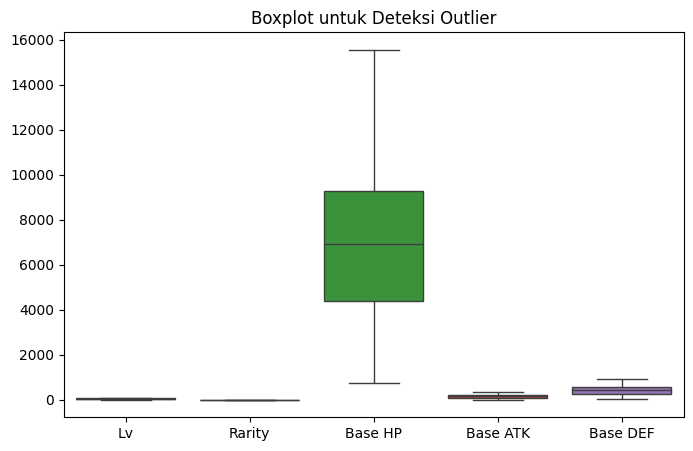

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)   # df = dataframe kamu
plt.title("Boxplot untuk Deteksi Outlier")
plt.show()

Mesin hanya bisa membaca angka, sehingga data perlu diubah.
* **LabelEncoder:** Mengubah data kategori teks (seperti nama Element atau Role) menjadi angka.
* **StandardScaler:** Menyamakan skala nilai statistik (seperti HP, ATK, dan DEF) agar model tidak berat sebelah dalam menilai atribut yang memiliki angka besar.

In [ ]:
le_element = LabelEncoder()
df['Element_Enc'] = le_element.fit_transform(df['Element'])

le_role = LabelEncoder()
df['Role_Enc'] = le_role.fit_transform(df['Main role'])

le_asc = LabelEncoder()
df['Ascension_Enc'] = le_asc.fit_transform(df['Ascension'])

# Label Target (Weapon)
le_weapon = LabelEncoder()
df['Weapon_Enc'] = le_weapon.fit_transform(df['Weapon'])
X = df[['Lv', 'Rarity', 'Element_Enc', 'Role_Enc', 'Ascension_Enc', 'Base HP', 'Base ATK', 'Base DEF']]
y = df['Weapon_Enc']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#EDA

Sel ini menghasilkan grafik **Heatmap Korelasi**. Tujuannya adalah untuk melihat variabel mana yang paling berpengaruh terhadap penentuan jenis senjata. Warna yang semakin kontras menunjukkan hubungan yang kuat antar variabel.

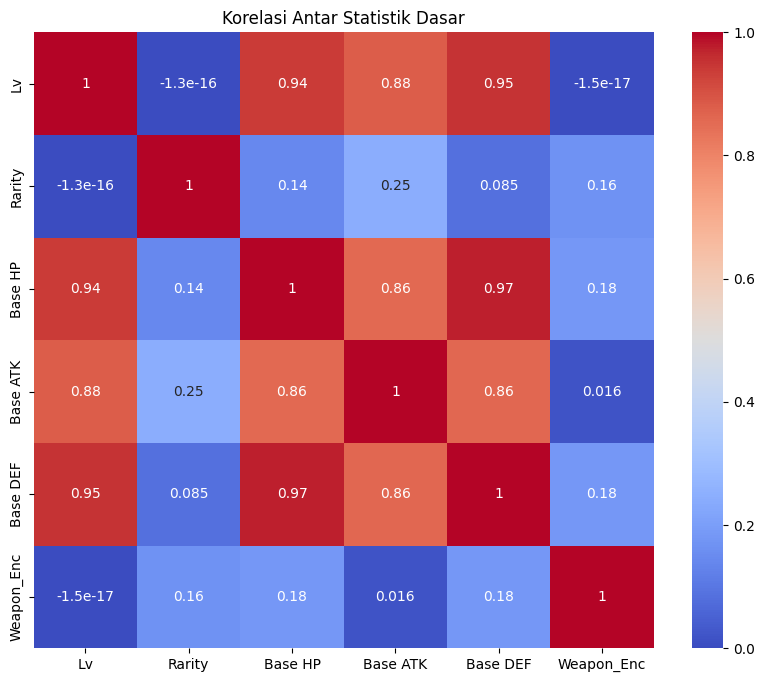

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Lv', 'Rarity', 'Base HP', 'Base ATK', 'Base DEF', 'Weapon_Enc']].corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Antar Statistik Dasar")
plt.show()


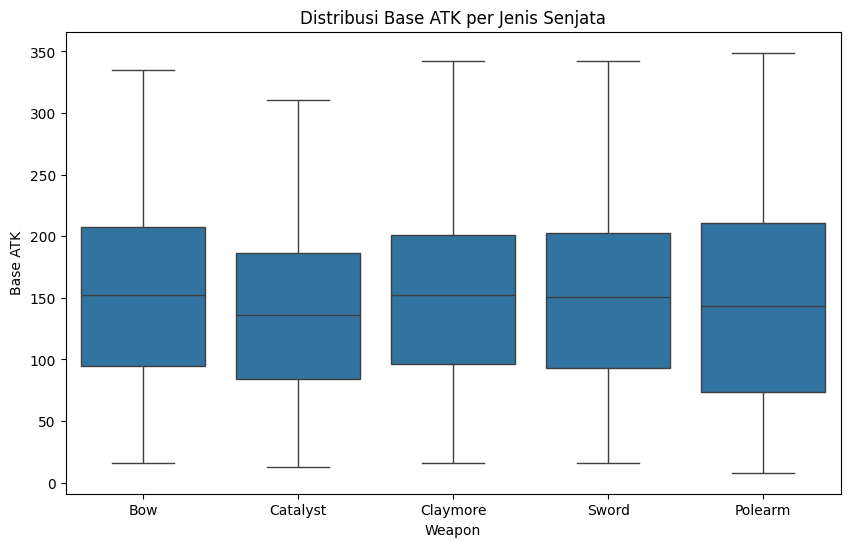

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weapon', y='Base ATK', data=df)
plt.title("Distribusi Base ATK per Jenis Senjata")
plt.show()

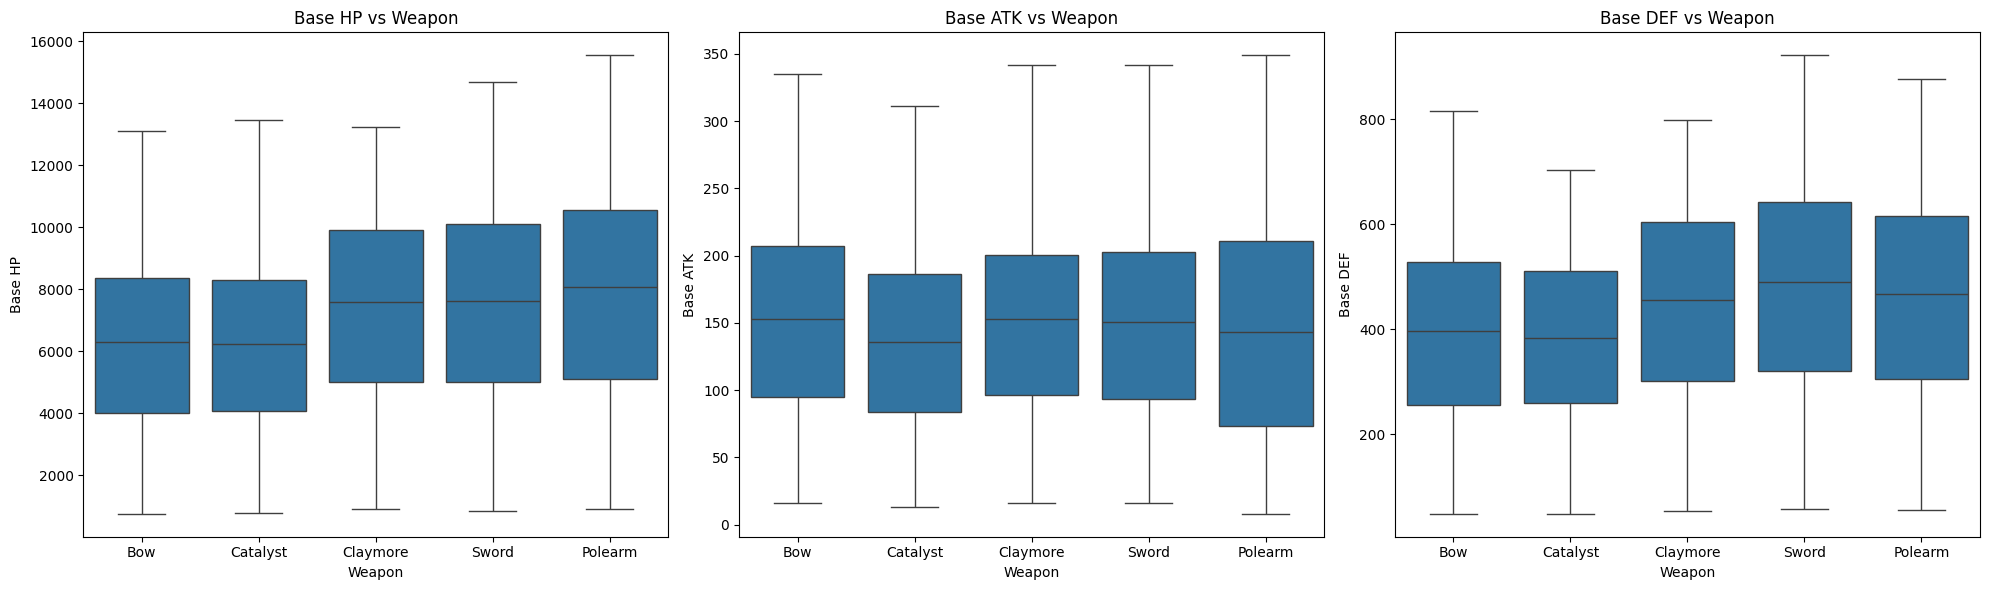

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.boxplot(x='Weapon', y='Base HP', data=df, ax=axes[0]).set_title('Base HP vs Weapon')
sns.boxplot(x='Weapon', y='Base ATK', data=df, ax=axes[1]).set_title('Base ATK vs Weapon')
sns.boxplot(x='Weapon', y='Base DEF', data=df, ax=axes[2]).set_title('Base DEF vs Weapon')
plt.tight_layout()
plt.show()

#Splitting Data

In [ ]:
ratios = [0.3, 0.2, 0.1]
ratio_labels = ['70:30', '80:20', '90:10']
results_list = []

#Hyperparameter Tunning

Ini adalah otak dari proyek ini. Kode akan melatih 5 algoritma berbeda sekaligus:
1.  **Random Forest:** Menggunakan kumpulan pohon keputusan untuk stabilitas tinggi.
2.  **SVM (Support Vector Machine):** Mencari batas pemisah terbaik antar kategori.
3.  **K-Nearest Neighbors (KNN):** Mengelompokkan berdasarkan kemiripan data terdekat.
4.  **Decision Tree:** Model logika pohon keputusan.
5.  **Logistic Regression:** Model statistik dasar untuk klasifikasi.

In [ ]:
split_configs = [0.3, 0.2, 0.1] # Test size: 30%, 20%, 10%
algorithms = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {'C': [1, 10, 100], 'kernel': ['linear', 'rbf']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
    }
}


In [ ]:
for i, test_size in enumerate(ratios):
    label = ratio_labels[i]
    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                        random_state=42, stratify=y)

    # Normalisasi (Penting untuk SVM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, mp in algorithms.items():
        # Hyperparameter Tuning menggunakan Grid Search
        clf = GridSearchCV(mp['model'], mp['params'], cv=3, scoring='accuracy', n_jobs=-1)
        clf.fit(X_train_scaled, y_train)

        # Prediksi
        y_pred = clf.best_estimator_.predict(X_test_scaled)

#Evaluation

Setelah belajar, model diuji dengan data yang belum pernah ia lihat.
* **Akurasi:** Menampilkan persentase seberapa sering model menebak dengan benar.
* **Confusion Matrix:** Tabel detail yang menunjukkan senjata apa yang paling sering ditebak dengan benar dan senjata apa yang sering tertukar.

In [ ]:
all_results = []

for test_size in split_configs:
    train_label = f"{int((1-test_size)*100)}:{int(test_size*100)}"
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42, stratify=y)

    for name, config in algorithms.items():
        # Hyperparameter Tuning dengan Grid Search
        grid = GridSearchCV(config['model'], config['params'], cv=3, scoring='accuracy')
        grid.fit(X_train, y_train)

        # Evaluasi
        y_pred = grid.best_estimator_.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        all_results.append({
            'Split Ratio': train_label,
            'Algorithm': name,
            'Accuracy': acc,
            'Precision': precision_score(y_test, y_pred, average='weighted'),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1-Score': f1_score(y_test, y_pred, average='weighted')
        })

In [ ]:
results_df = pd.DataFrame(all_results)

print("\n=== HASIL PERFORMA 3 ALGORITMA ===\n")
print(results_df)


=== HASIL PERFORMA 3 ALGORITMA ===

  Split Ratio      Algorithm  Accuracy  Precision    Recall  F1-Score
0       70:30  Random Forest  0.867052   0.867387  0.867052  0.866822
1       70:30            SVM  0.976879   0.977673  0.976879  0.976789
2       70:30  Decision Tree  0.861272   0.864714  0.861272  0.861004
3       80:20  Random Forest  0.852174   0.853645  0.852174  0.851526
4       80:20            SVM  1.000000   1.000000  1.000000  1.000000
5       80:20  Decision Tree  0.843478   0.844017  0.843478  0.843367
6       90:10  Random Forest  0.827586   0.834322  0.827586  0.828128
7       90:10            SVM  1.000000   1.000000  1.000000  1.000000
8       90:10  Decision Tree  0.862069   0.878140  0.862069  0.863833


In [ ]:
print("\n=== RATA-RATA PERFORMA PER ALGORITMA ===\n")
mean_results = results_df.groupby("Algorithm")[["Accuracy","Precision","Recall","F1-Score"]].mean()
print(mean_results)


=== RATA-RATA PERFORMA PER ALGORITMA ===

               Accuracy  Precision    Recall  F1-Score
Algorithm                                             
Decision Tree  0.855606   0.862290  0.855606  0.856068
Random Forest  0.848937   0.851785  0.848937  0.848825
SVM            0.992293   0.992558  0.992293  0.992263


In [ ]:
# Jalankan ini sebelum kode Confusion Matrix untuk mendapatkan hasil SVM (90:10)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42, stratify=y)
best_svc = GridSearchCV(SVC(random_state=42), {'C': [1, 10, 100], 'kernel': ['linear', 'rbf']}, cv=3)
best_svc.fit(X_train, y_train)

y_pred = best_svc.best_estimator_.predict(X_test)
# Baru kemudian jalankan plot Confusion Matrix Anda

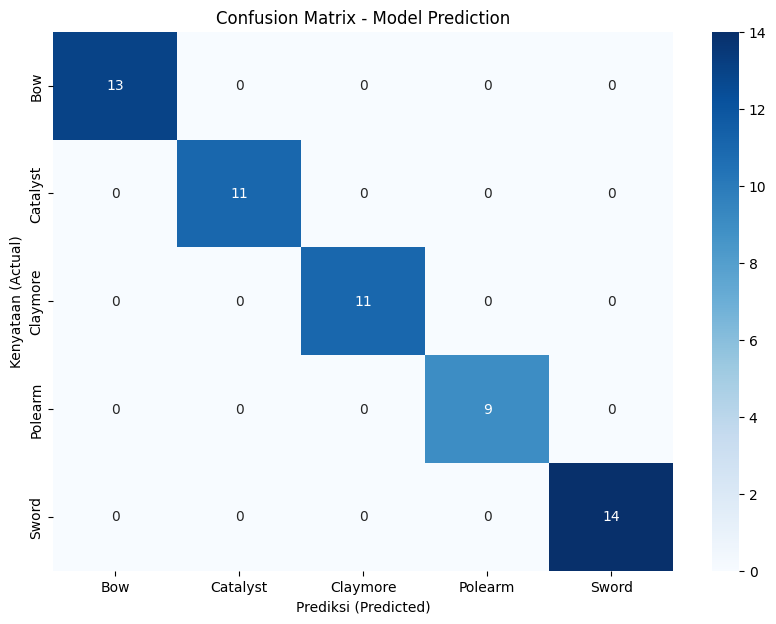

In [ ]:
# 1. Menghitung Confusion Matrix
# Pastikan y_test dan y_pred adalah data dari model yang ingin Anda evaluasi
cm = confusion_matrix(y_test, y_pred)

# 2. Membuat Plot
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_weapon.classes_,
            yticklabels=le_weapon.classes_)

plt.title('Confusion Matrix - Model Prediction')
plt.xlabel('Prediksi (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.show()

#Model Comparasion

In [ ]:
results_df = pd.DataFrame(all_results)

# Tabel Perbandingan
print("\n--- Tabel Perbandingan Performa ---")
print(results_df.sort_values(by='Accuracy', ascending=False))


--- Tabel Perbandingan Performa ---
  Split Ratio      Algorithm  Accuracy  Precision    Recall  F1-Score
4       80:20            SVM  1.000000   1.000000  1.000000  1.000000
7       90:10            SVM  1.000000   1.000000  1.000000  1.000000
1       70:30            SVM  0.976879   0.977673  0.976879  0.976789
0       70:30  Random Forest  0.867052   0.867387  0.867052  0.866822
8       90:10  Decision Tree  0.862069   0.878140  0.862069  0.863833
2       70:30  Decision Tree  0.861272   0.864714  0.861272  0.861004
3       80:20  Random Forest  0.852174   0.853645  0.852174  0.851526
5       80:20  Decision Tree  0.843478   0.844017  0.843478  0.843367
6       90:10  Random Forest  0.827586   0.834322  0.827586  0.828128


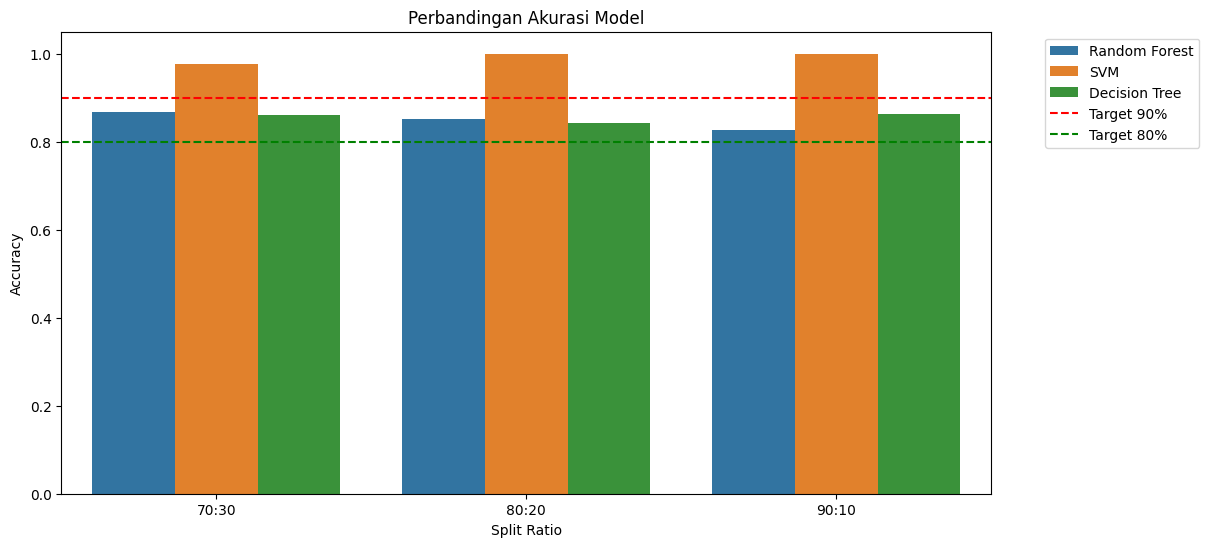

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Split Ratio', y='Accuracy', hue='Algorithm', data=results_df)
plt.axhline(0.90, color='red', linestyle='--', label='Target 90%')
plt.axhline(0.80, color='green', linestyle='--', label='Target 80%')
plt.title("Perbandingan Akurasi Model")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# Contoh: Mengambil model terbaik dari hasil GridSearchCV terakhirmu
best_model = grid.best_estimator_

# Simpan model dan scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Simpan LabelEncoder untuk mengembalikan angka ke nama Senjata (Bow, Sword, dll)
joblib.dump(le_weapon, 'label_encoder_weapon.pkl')

['label_encoder_weapon.pkl']

Sel terakhir adalah pembuktian.
* Di sini kita memasukkan data karakter baru yang belum ada di dataset.
* Model akan memberikan hasil prediksi akhir (seperti "Claymore", "Polearm", atau "Sword") berdasarkan statistik atribut yang diberikan.

In [ ]:
# 1. Load Artefak Model dan Preprocessing
# Pastikan file-file ini ada di direktori yang sama
try:
    model = joblib.load('best_model.pkl')
    scaler = joblib.load('scaler.pkl')
    le_weapon = joblib.load('label_encoder_weapon.pkl')

    # Karena kita butuh encoder untuk fitur input juga,
    # idealnya kamu menyimpan le_element, le_role, dan le_asc di notebook sebelumnya.
    # Jika tidak disimpan, kita perlu mendefinisikannya ulang berdasarkan data asli:
    df_original = pd.read_csv('Genshin_Impact_All_Character_Stat.csv')

    from sklearn.preprocessing import LabelEncoder
    le_element = LabelEncoder().fit(df_original['Element'])
    le_role = LabelEncoder().fit(df_original['Main role'])
    le_asc = LabelEncoder().fit(df_original['Ascension'])

    print("Model dan Encoder berhasil dimuat.")
except Exception as e:
    print(f"Error saat memuat model/data: {e}")

# 2. Fungsi Simulasi Data Baru
def simulate_new_characters(n=5):
    """Menghasilkan n data karakter baru secara acak"""
    data = {
        'Character': [f'NewChar_{i}' for i in range(n)],
        'Lv': np.random.choice([1, 20, 40, 50, 60, 70, 80, 90], n),
        'Rarity': np.random.choice([4, 5], n),
        'Element': np.random.choice(df_original['Element'].unique(), n),
        'Main role': np.random.choice(df_original['Main role'].unique(), n),
        'Ascension': np.random.choice(df_original['Ascension'].unique(), n),
        'Base HP': np.random.randint(700, 15000, n),
        'Base ATK': np.random.randint(10, 350, n),
        'Base DEF': np.random.randint(50, 950, n)
    }
    return pd.DataFrame(data)

# 3. Jalankan Simulasi
new_data = simulate_new_characters(5)
print("\n--- Data Baru yang Disimulasikan ---")
print(new_data.head())

# 4. Preprocessing Data Baru untuk Prediksi
# Transformasi kategori ke angka
new_data_prep = new_data.copy()
new_data_prep['Element_Enc'] = le_element.transform(new_data['Element'])
new_data_prep['Role_Enc'] = le_role.transform(new_data['Main role'])
new_data_prep['Ascension_Enc'] = le_asc.transform(new_data['Ascension'])

# Pilih fitur yang sesuai dengan saat training
features = ['Lv', 'Rarity', 'Element_Enc', 'Role_Enc', 'Ascension_Enc', 'Base HP', 'Base ATK', 'Base DEF']
X_new = new_data_prep[features]

# Scaling
X_new_scaled = scaler.transform(X_new)

# 5. Prediksi
predictions = model.predict(X_new_scaled)
predicted_weapons = le_weapon.inverse_transform(predictions)

# Tampilkan Hasil
new_data['Predicted Weapon'] = predicted_weapons
print("\n--- Hasil Prediksi Senjata untuk Data Simulasi ---")
print(new_data[['Character', 'Element', 'Main role', 'Base ATK', 'Predicted Weapon']])

Model dan Encoder berhasil dimuat.

--- Data Baru yang Disimulasikan ---
   Character  Lv  Rarity  Element Main role     Ascension  Base HP  Base ATK  \
0  NewChar_0  80       4    Hydro       DPS           DEF     7749       124   
1  NewChar_1  90       5    Anemo   Sub DPS      Pyro DMG     5522       346   
2  NewChar_2  90       5  Electro   Support  Physical DMG     3558       106   
3  NewChar_3  50       5    Anemo   Support  Physical DMG     4203       150   
4  NewChar_4  50       5      Geo       DPS      Cryo DMG     6731       156   

   Base DEF  
0       723  
1       806  
2       197  
3       830  
4       672  

--- Hasil Prediksi Senjata untuk Data Simulasi ---
   Character  Element Main role  Base ATK Predicted Weapon
0  NewChar_0    Hydro       DPS       124         Claymore
1  NewChar_1    Anemo   Sub DPS       346            Sword
2  NewChar_2  Electro   Support       106          Polearm
3  NewChar_3    Anemo   Support       150            Sword
4  NewChar_4   